In [1]:
import merlin_spectra
from merlin_spectra.emission import EmissionLineInterpolator

In [2]:
import os
import sys
import copy

import numpy as np
import yt
from yt.frontends.ramses.field_handlers import RTFieldFileHandler
import astropy.units as u
# import galaxy_visualization

In [3]:
filename = "/Users/lamoreau/python/ASpec/SimulationFiles/output_00273/info_00273.txt"

lines=["H1_6562.80A","O1_1304.86A","O1_6300.30A","O2_3728.80A","O2_3726.10A",
       "O3_1660.81A","O3_1666.15A","O3_4363.21A","O3_4958.91A","O3_5006.84A", 
       "He2_1640.41A","C2_1335.66A","C3_1906.68A","C3_1908.73A","C4_1549.00A",
       "Mg2_2795.53A","Mg2_2802.71A","Ne3_3868.76A","Ne3_3967.47A",
       "N5_1238.82A",
       "N5_1242.80A","N4_1486.50A","N3_1749.67A","S2_6716.44A","S2_6730.82A"]

wavelengths=[6562.80, 1304.86, 6300.30, 3728.80, 3726.10, 1660.81, 1666.15,
             4363.21, 4958.91, 5006.84, 1640.41, 1335.66,
             1906.68, 1908.73, 1549.00, 2795.53, 2802.71, 3868.76,
             3967.47, 1238.82, 1242.80, 1486.50, 1749.67, 6716.44, 6730.82]

cell_fields = [
    "Density",
    "x-velocity",
    "y-velocity",
    "z-velocity",
    "Pressure",
    "Metallicity",
    "xHI",
    "xHII",
    "xHeII",
    "xHeIII",
]

epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

# Ionization Parameter Field
# Based on photon densities in bins 2-4
# Don't include bin 1 -> Lyman Werner non-ionizing
def _ion_param(field, data):
    p = RTFieldFileHandler.get_rt_parameters(ds).copy()
    p.update(ds.parameters)

    cgs_c = 2.99792458e10     #light velocity

    # Convert to physical photon number density in cm^-3
    pd_2 = data['ramses-rt','Photon_density_2']*p["unit_pf"]/cgs_c
    pd_3 = data['ramses-rt','Photon_density_3']*p["unit_pf"]/cgs_c
    pd_4 = data['ramses-rt','Photon_density_4']*p["unit_pf"]/cgs_c

    photon = pd_2 + pd_3 + pd_4

    return photon/data['gas', 'number_density']


def _my_temperature(field, data):
    #y(i): abundance per hydrogen atom
    XH_RAMSES=0.76 #defined by RAMSES in cooling_module.f90
    YHE_RAMSES=0.24 #defined by RAMSES in cooling_module.f90
    mH_RAMSES=yt.YTArray(1.6600000e-24,"g") #defined by RAMSES in cooling_module.f90
    kB_RAMSES=yt.YTArray(1.3806200e-16,"erg/K") #defined by RAMSES in cooling_module.f90

    dn=data["ramses","Density"].in_cgs()
    pr=data["ramses","Pressure"].in_cgs()
    yHI=data["ramses","xHI"]
    yHII=data["ramses","xHII"]
    yHe = YHE_RAMSES*0.25/XH_RAMSES
    yHeII=data["ramses","xHeII"]*yHe
    yHeIII=data["ramses","xHeIII"]*yHe
    yH2=1.-yHI-yHII
    yel=yHII+yHeII+2*yHeIII
    mu=(yHI+yHII+2.*yH2 + 4.*yHe) / (yHI+yHII+yH2 + yHe + yel)
    return pr/dn * mu * mH_RAMSES / kB_RAMSES


# TODO see if it works in emission.py
# Luminosity field
# Cloudy Intensity obtained assuming height = 1cm
# Return intensity values erg/s/cm**2
# Multiply intensity at each pixel by volume of pixel -> luminosity
def get_luminosity(line):
   def _luminosity(field, data):
      return data['gas', 'flux_' + line]*data['gas', 'volume']
   return copy.deepcopy(_luminosity)


#number density of hydrogen atoms
def _my_H_nuclei_density(field, data):
    dn=data["ramses","Density"].in_cgs()
    XH_RAMSES=0.76 #defined by RAMSES in cooling_module.f90
    YHE_RAMSES=0.24 #defined by RAMSES in cooling_module.f90
    mH_RAMSES=yt.YTArray(1.6600000e-24,"g") #defined by RAMSES in cooling_module.f90

    return dn*XH_RAMSES/mH_RAMSES


def _pressure(field, data):
    if 'hydro_thermal_pressure' in dir(ds.fields.ramses): # and 
        #'Pressure' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_thermal_pressure']


def _xHI(field, data):
    if 'hydro_xHI' in dir(ds.fields.ramses): # and \
        #'xHI' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHI']


def _xHII(field, data):
    if 'hydro_xHII' in dir(ds.fields.ramses): # and \
        #'xHII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHII']


def _xHeII(field, data):
    if 'hydro_xHeII' in dir(ds.fields.ramses): # and \
        #'xHeII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHeII']


def _xHeIII(field, data):
    if 'hydro_xHeIII' in dir(ds.fields.ramses): # and \
        #'xHeIII' not in dir(ds.fields.ramses):
        return data['ramses', 'hydro_xHeIII']


In [4]:
'''
-------------------------------------------------------------------------------
Load Simulation Data
Add Derived Fields
-------------------------------------------------------------------------------
'''

ds = yt.load(filename, extra_particle_fields=epf)

ds.add_field(
    ("gas","number_density"),
    function=_my_H_nuclei_density,
    sampling_type="cell",
    units="1/cm**3",
    force_override=True
)


ds.add_field(
    ("ramses","Pressure"),
    function=_pressure,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHI"),
    function=_xHI,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHII"),
    function=_xHII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHeII"),
    function=_xHeII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("ramses","xHeIII"),
    function=_xHeIII,
    sampling_type="cell",
    units="1",
    #force_override=True
)

ds.add_field(
    ("gas","my_temperature"),
    function=_my_temperature,
    sampling_type="cell",
    # TODO units
    #units="K",
    #units="K*cm**3/erg",
    units='K*cm*dyn/erg',
    force_override=True
)

# Ionization parameter
ds.add_field(
    ('gas', 'ion_param'),
    function=_ion_param,
    sampling_type="cell",
    units="cm**3",
    force_override=True
)

ds.add_field(
    ("gas","my_H_nuclei_density"),
    function=_my_H_nuclei_density,
    sampling_type="cell",
    units="1/cm**3",
    force_override=True
)

# Normalize by Density Squared Flag
dens_normalized = True
if dens_normalized: 
    units = '1/cm**6'
else:
    units = '1'

# Instance of EmissionLineInterpolator for line list at filename
merlin_path = os.path.dirname(merlin_spectra.__file__)
# Path to the linelists folder inside MERLIN
line_list = os.path.join(merlin_path, "linelists/linelist.dat")

emission_interpolator = EmissionLineInterpolator(lines, line_list)

# Add flux and luminosity fields for all lines in the list
for i, line in enumerate(lines):
    ds.add_field(
        ('gas', 'flux_' + line),
        function=emission_interpolator.get_line_emission(
            i, dens_normalized=dens_normalized
        ),
        sampling_type='cell',
        units=units,
        force_override=True
    )
    # TODO change get_line_emission to accept line not idx

    ds.add_field(
        ('gas', 'luminosity_' + line),
        function=emission_interpolator.get_luminosity(lines[i]),
        #function=get_luminosity(lines[i]),
        sampling_type='cell',
        units='1/cm**3',
        force_override=True
    )

ad = ds.all_data()
print(ds.field_list)
# fv = sorted(set(t[0] for t in ds.field_list))

# print(fv)
# print(set(i for i in ad['io', 'particle_family'].value))
# star_px = ad[("star", "particle_position_x")]
#print(ad["star", ""])

yt : [WARNING  ] 2026-05-08 19:01:25,668 `namelist.txt` file found but missing package f90nml to read it:
Traceback (most recent call last):
  File "/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/yt/frontends/ramses/data_structures.py", line 1139, in read_namelist
    nml = f90nml.read(f)
  File "/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/yt/utilities/on_demand_imports.py", line 39, in __call__
    raise self.error
  File "/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/yt/utilities/on_demand_imports.py", line 77, in inner
    return func(self)
  File "/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/yt/utilities/on_demand_imports.py", line 420, in read
    from f90nml import read
ModuleNotFoundError: No module named 'f90nml'
Something went wrong while trying to lazy-import f90nml. Please make sure that f90nml is properly installed.
If the problem persists, please file an issue at https://github.com/yt-project/yt/issues/n

/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/merlin_spectra/linelists/linelist-all.dat
/Users/lamoreau/pyS99/pyS99/.venv/lib/python3.10/site-packages/merlin_spectra/linelists/linelist-all.dat
minU=-9.0, maxU=2.0, stepU=0.5, minN=-4.0, maxN=7.0, stepN=0.5, minT=1.0, maxT=8.0, stepT=0.2
Line List Shape = (26, 19044)
23 23 36
[('gravity', 'Potential'), ('gravity', 'x-acceleration'), ('gravity', 'y-acceleration'), ('gravity', 'z-acceleration'), ('io', 'particle_birth_epoch'), ('io', 'particle_family'), ('io', 'particle_identity'), ('io', 'particle_mass'), ('io', 'particle_metallicity'), ('io', 'particle_position_x'), ('io', 'particle_position_y'), ('io', 'particle_position_z'), ('io', 'particle_refinement_level'), ('io', 'particle_tag'), ('io', 'particle_velocity_x'), ('io', 'particle_velocity_y'), ('io', 'particle_velocity_z'), ('nbody', 'particle_mass'), ('nbody', 'particle_position_x'), ('nbody', 'particle_position_y'), ('nbody', 'particle_position_z'), ('nbody', 'part

#### Note, x_offsets are all positive meaning the slit lies on the right on the galaxy center, y_offsets are relatively centered to galaxy itself

In [5]:
# x and y offsets from the galaxy center 
# x_kpc = [-0.05534755,-0.0354541,0.11149605,0.09188019]  #kpc
# y_kpc = [-0.10703977,-0.05807763,0.35900177,0.30995199] #kpc
x_kpc = [2.67986217, 3.9913081,  4.29056273, 3.04533859]
y_kpc = [ 5.38216675, 10.85668,    11.75003228,  6.25405556]
# rect region bound
x_max = np.max(x_kpc)
x_min = np.min(x_kpc)
y_max = np.max(y_kpc)
y_min = np.min(y_kpc)

print(x_max)
print(y_max)

4.29056273
11.75003228


In [6]:
# creating proj of a boxed region
cx = np.mean(ad["star", "particle_position_x"])
cy = np.mean(ad["star", "particle_position_y"])
cz = np.mean(ad["star", "particle_position_z"])
center = [cx, cy, cz]
# needed for addition with unitary quantaties
x_min_u = ds.quan(x_min, "kpc")
x_max_u = ds.quan(x_max, "kpc")
y_min_u = ds.quan(y_min, "kpc")
y_max_u = ds.quan(y_max, "kpc")
low_edge = [center[0] + x_min_u, center[1] + y_min_u , ds.domain_left_edge[2]]
high_edge = [center[0] + x_max_u, center[1] + y_max_u, ds.domain_right_edge[2]]

cube_region = ds.region(center, low_edge, high_edge)

ad_box = cube_region

# cell_volume_box = ad_box["cell_volume"]   # in cm^3
# print(cell_volume)
# # ----------------------------------------------------
# # OUTPUT ARRAYS
# # ----------------------------------------------------
# total_fluxes_box = []
# total_luminosities_box = []

yt : [INFO     ] 2026-05-08 19:01:27,873 Identified   384/  384 intersecting domains (  385 through hilbert key indexing)


### Getting ages for SFCs

In [9]:
unit_t = ds.parameters["unit_t"]  # seconds
time_now_Myr = ds.current_time.to("Myr").value * u.Myr  # 360.4 Myr

# Birth epoch is dimensionless in yt, multiply by unit_t to get seconds
star_birth_offset = ad["star", "particle_birth_epoch"].v * unit_t * u.s

# Formation time (cosmic time when star was born)
formation_time_Myr = time_now_Myr + star_birth_offset.to(u.Myr)

# Stellar age
star_age_Myr = time_now_Myr - formation_time_Myr
print(star_age_Myr)

[77.99077649 77.99643051 77.99643051 ... 77.6266588  77.62674212
 77.70094682] Myr


#### selecting the projection region

In [8]:
from matplotlib.path import Path

slit_vertices = np.column_stack((x_kpc, y_kpc))
poly = Path(slit_vertices)    # defines a polygon with the traced points

# ----- creating mask ----
x = ad_box["gas", "x"].to("kpc")
y = ad_box["gas", "y"].to("kpc")
z = ad_box["gas", "z"].to("kpc")
sx = ad_box["star", "particle_position_x"].to("kpc")
sy = ad_box["star", "particle_position_y"].to("kpc")
sz = ad_box["star", "particle_position_z"].to("kpc")
# since we defiend the slit relative to galaxy center, gas particles also needs to be defined relative to the galaxy center
x_rel = (x - center[0]).value
y_rel = (y - center[1]).value
sx_rel = (sx - center[0]).value
sy_rel = (sy - center[0]).value
points = np.column_stack((x_rel, y_rel))  # test points 
spoints = np.column_stack((sx_rel, sy_rel))
mask = poly.contains_points(points)
smask = poly.contains_points(spoints)
print(mask)

KeyboardInterrupt: 

In [ ]:
print(np.any(mask))  # there are cells inside the rectangualr box that falls within the traced slit
print(np.any(smask))

True
False


## getting flux and intesnites

In [ ]:
cell_volume_box = ad_box["cell_volume"]   # cm^3
cell_volume_slit = cell_volume_box[mask]  # getting only necessary cells
total_fluxes_slit = []
total_luminosities_slit = []

In [ ]:
for line in lines:

    flux_field = ("gas", f"flux_{line}")
    lum_field  = ("gas", f"luminosity_{line}")

    flux = ad_box[flux_field][mask]
    lum  = ad_box[lum_field][mask]

    total_flux = (flux * cell_volume_slit).sum()
    total_lum  = lum.sum()

    total_fluxes_slit.append(total_flux)
    total_luminosities_slit.append(total_lum)

In [ ]:
print(3e8 / (6536*1e-10))  # H-alpha line in frequency


458996328029375.8


In [ ]:
print(total_fluxes_slit)
print(total_luminosities_slit)

[unyt_quantity(6.51008365e+33, 'cm**(-3)'), unyt_quantity(6.35193028e-38, 'cm**(-3)'), unyt_quantity(4.2085907e-40, 'cm**(-3)'), unyt_quantity(2.57656944e-37, 'cm**(-3)'), unyt_quantity(5.85573354e-38, 'cm**(-3)'), unyt_quantity(3.8938988e-38, 'cm**(-3)'), unyt_quantity(7.28300709e-48, 'cm**(-3)'), unyt_quantity(2.13287924e-47, 'cm**(-3)'), unyt_quantity(3.25033881e-47, 'cm**(-3)'), unyt_quantity(3.37177505e-45, 'cm**(-3)'), unyt_quantity(1.07214949e+25, 'cm**(-3)'), unyt_quantity(2.11819576e-113, 'cm**(-3)'), unyt_quantity(1.70465837e-40, 'cm**(-3)'), unyt_quantity(3.58178694e-42, 'cm**(-3)'), unyt_quantity(2.37427333e-42, 'cm**(-3)'), unyt_quantity(0., 'cm**(-3)'), unyt_quantity(4.10759878e-37, 'cm**(-3)'), unyt_quantity(2.08057328e-37, 'cm**(-3)'), unyt_quantity(5.85589638e-44, 'cm**(-3)'), unyt_quantity(1.77738933e-44, 'cm**(-3)'), unyt_quantity(0., 'cm**(-3)'), unyt_quantity(0., 'cm**(-3)'), unyt_quantity(0., 'cm**(-3)'), unyt_quantity(1.89798926e-46, 'cm**(-3)'), unyt_quantity(4.

In [ ]:
line = lines[0]
flux_field = ("gas", f"flux_{line}")
lum_field  = ("gas", f"luminosity_{line}")

print(ad_box[flux_field].units)
print(ad_box[lum_field].units)
print(ad_box["cell_volume"].units)

cm**(-6)
cm**(-3)
cm**3


In [ ]:
### Import Statements ###
import numpy as np
from numpy import ndarray
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import c
from astropy.cosmology import FlatLambdaCDM

### Function Definition (Need more comments) ###
def ergcm2s_to_jyhz(F_erg_cm2_s):
    # 1 erg/s/cm^2 = 1e23 Jy Hz

    return F_erg_cm2_s * 1e23

def gaussian_spectrum_from_integrated_flux_erg(
    lambda_array: ndarray,          # wavelength grid (Å)
    line_cents_array: ndarray,      # line centers (Å)
    sigma_v_kms: ndarray,           # Gaussian sigma in km/s (scalar or array)
    F_line_erg_cm2_s: ndarray       # assuming integrated fluxes are in correct unit: (erg/s/cm^2), array 
):
    """
    Returns the combined line spectrum S(λ) in Jy.
    Gaussian profile defined in frequency domain but evaluated on λ grid.
    """

    # ---- Convert inputs to arrays ----
    lambda_array = np.asarray(lambda_array, float)        # (Nλ,)
    line_cents_array = np.asarray(line_cents_array, float)  # (Nlines,)
    sigma_v_kms = np.asarray(sigma_v_kms, float)            # scalar or (Nlines,)
    F_line_erg_cm2_s = np.asarray(F_line_erg_cm2_s, float)  # (Nlines,)

    # ---- Convert wavelength to frequency ----
    # Å → cm
    lam_cm = lambda_array * 1e-8
    lam0_cm = line_cents_array * 1e-8

    # λ → ν conversion
    nu_array = c.cgs.to_value() / lam_cm         # Hz, shape (Nλ,)
    nu0 = c.cgs.to_value()  / lam0_cm             # Hz, shape (Nlines,)

    # ---- Convert integrated flux to (Jy Hz) ----
    F_jyhz = ergcm2s_to_jyhz(F_line_erg_cm2_s)  # shape (Nlines,)

    # ---- Convert sigma_v → sigma_nu ---- # frankly don't know how this works
    sigma_nu = (nu0 / 2.99792458e5) * sigma_v_kms   # km/s to Hz

    # ---- Gaussian amplitude in Jy ----
    A_jy = F_jyhz / (sigma_nu * np.sqrt(2*np.pi))

    # ---- Broadcast Gaussian calculation ----
    # nu_array: (Nλ,) → (1, Nλ)
    # nu0:      (Nlines,) → (Nlines, 1)
    nu_diff = nu_array[None, :] - nu0[:, None]

    S_each = A_jy[:, None] * np.exp(-0.5 * (nu_diff / sigma_nu[:, None])**2)

    # ---- Sum over all lines ----
    S_total = np.sum(S_each, axis=0)

    return S_total

['1.45297765e+39', '8.97463982e+31', '1.36882452e+34', '3.52808024e+34', '2.72519332e+34', '4.49457814e+31', '1.31624231e+32', '3.93634382e+31', '3.32020556e+32', '9.9060586e+32', '1.0549357e+34', '1.93802964e+32', '1.71747298e+33', '1.11501585e+33', '8.32327063e+28', '3.922054e+34', '1.98474348e+34', '2.19550288e+31', '6.66373684e+30', '4.93719524e+31', '2.46248953e+31', '2.23667185e+29', '7.14361445e+31', '4.39563797e+34', '3.47217011e+34']
25 25


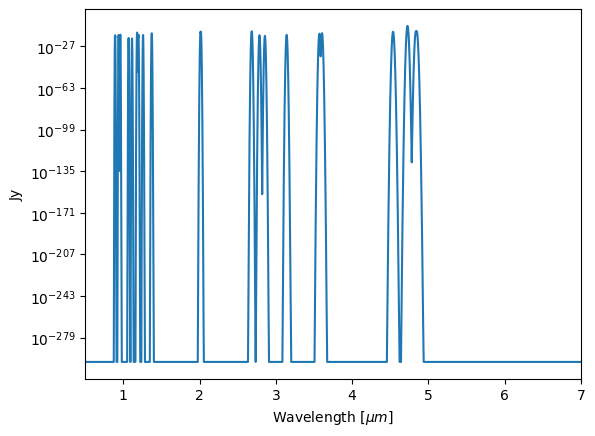

In [ ]:
if __name__ == "__main__":
    import re
    # wavelengths = np.array([
    #     6562.80, 1304.86, 6300.30, 3728.80, 3726.10,
    #     1660.81, 1666.15, 4363.21, 4958.91, 5006.84,
    #     1640.41, 1335.66, 1906.68, 1908.73, 1549.00,
    #     2795.53, 2802.71, 3868.76, 3967.47, 1238.82,
    #     1242.80, 1486.50, 1749.67, 6716.44, 6730.82])
    
    wavelengths=[6562.80, 1304.86, 6300.30, 3728.80, 3726.10, 1660.81, 1666.15,
             4363.21, 4958.91, 5006.84, 1640.41, 1335.66,
             1906.68, 1908.73, 1549.00, 2795.53, 2802.71, 3868.76,
             3967.47, 1238.82, 1242.80, 1486.50, 1749.67, 6716.44, 6730.82]

    ashiq_in = "unyt_quantity(1.45297765e+39, 'cm**(-3)'), unyt_quantity(8.97463982e+31, 'cm**(-3)'), unyt_quantity(1.36882452e+34, 'cm**(-3)'), unyt_quantity(3.52808024e+34, 'cm**(-3)'), unyt_quantity(2.72519332e+34, 'cm**(-3)'), unyt_quantity(4.49457814e+31, 'cm**(-3)'), unyt_quantity(1.31624231e+32, 'cm**(-3)'), unyt_quantity(3.93634382e+31, 'cm**(-3)'), unyt_quantity(3.32020556e+32, 'cm**(-3)'), unyt_quantity(9.9060586e+32, 'cm**(-3)'), unyt_quantity(1.0549357e+34, 'cm**(-3)'), unyt_quantity(1.93802964e+32, 'cm**(-3)'), unyt_quantity(1.71747298e+33, 'cm**(-3)'), unyt_quantity(1.11501585e+33, 'cm**(-3)'), unyt_quantity(8.32327063e+28, 'cm**(-3)'), unyt_quantity(3.922054e+34, 'cm**(-3)'), unyt_quantity(1.98474348e+34, 'cm**(-3)'), unyt_quantity(2.19550288e+31, 'cm**(-3)'), unyt_quantity(6.66373684e+30, 'cm**(-3)'), unyt_quantity(4.93719524e+31, 'cm**(-3)'), unyt_quantity(2.46248953e+31, 'cm**(-3)'), unyt_quantity(2.23667185e+29, 'cm**(-3)'), unyt_quantity(7.14361445e+31, 'cm**(-3)'), unyt_quantity(4.39563797e+34, 'cm**(-3)'), unyt_quantity(3.47217011e+34, 'cm**(-3)')"
    pattern = re.compile(r"unyt_quantity\(([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")
    hits = pattern.findall(ashiq_in)
    print(hits)

    L_values = np.array(hits, dtype=float)  # erg/s  These are total lumonisty values 
    print(len(hits), len(L_values))

    # total intrinsic Lumonisity --> observed flux 
    z_test = 6.2  # source redshift
    cosmo = FlatLambdaCDM(H0=70 * u.km/u.s/u.Mpc, Om0=0.3)
    D_L = cosmo.luminosity_distance(z_test).to(u.cm).value
    F_values = L_values / (4 * np.pi * D_L**2)  # erg/s/cm^2
        
    
    # testx = np.linspace(200,10000,40000) * u.Angstrom
    # out = gaussian_spectrum_from_integrated_flux_erg(testx, wavelengths, 150, F_values)
    # testx_mic = (testx * (1+z_test)).to(u.micron)   # redshifted wavelength
    # plt.plot(testx_mic, out )
    # # plt.xlim(0.5,6)
    # # plt.ylim(-0.000001,0.00001)
    # plt.yscale("log")
    # plt.ylabel(r"$Jy$")
    # plt.show()
    # print(f"{wavelengths}\n{F_values}")

    testx = np.linspace(200,10000,200000) * u.Angstrom
    out = gaussian_spectrum_from_integrated_flux_erg(testx, wavelengths, 150, F_values)
    testx_mic = (testx * (1+z_test)).to(u.micron)   # redshifted wavelength

    out_plot = np.maximum(out, 1e-300)   # avoid log(0)

    plt.plot(testx_mic, out_plot)
    plt.yscale("log")
    plt.xlabel(r"Wavelength [$\mu m$]")
    plt.ylabel("Jy")
    plt.xlim(0.5, 7)   # optional, helps focus on JWST-like range
    plt.show()

In [ ]:
print("D_L cm =", D_L)
print("max L erg/s =", np.max(L_values))
print("max F erg/s/cm^2 =", np.max(F_values))
print("max out Jy =", np.max(out))

D_L cm = 1.850515723669253e+29
max L erg/s = 1.45297765e+39
max F erg/s/cm^2 = 3.376474784065323e-21
max out Jy = 5.893364201236333e-10


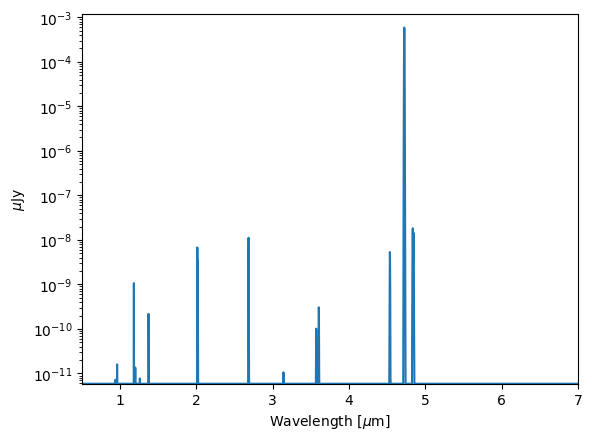

In [ ]:
out_microJy = out * 1e6

floor = np.nanmax(out_microJy) * 1e-8
out_plot = np.maximum(out_microJy, floor)  # floor to floor if values are too low. 

plt.plot(testx_mic, out_plot)
plt.yscale("log")
plt.xlim(0.5, 7)
plt.ylim(floor, np.nanmax(out_microJy) * 2)
plt.xlabel(r"Wavelength [$\mu$m]")
plt.ylabel(r"$\mu$Jy")
plt.show()

In [ ]:
# ----------------------------------------------------
# MAIN LOOP — compute integrated flux & luminosity
# ----------------------------------------------------
for line in lines:
    # field names MUST match how you added them
    flux_field = ("gas", f"flux_{line}")
    lum_field  = ("gas", f"luminosity_{line}")

    # read per-cell fields (with units)
    flux = ad_box[flux_field]                                                                                                                                                      
    lum  = ad_box[lum_field]           # units: erg/s

    # integrate over volume
    total_flux = (flux * cell_volume_box).sum()  
    total_lum  = (lum).sum()                     

    total_fluxes_box.append(total_flux)
    total_luminosities_box.append(total_lum)

# convert to yt arrays or numpy with units if needed
total_fluxes_box = np.array(total_fluxes_box) # unit: erg/s/cm^2
total_luminosities_box = np.array(total_luminosities_box)    #unit: erg/s

NameError: name 'total_fluxes_box' is not defined

In [ ]:
print(total_fluxes_box)
print(total_luminosities_box)

NameError: name 'total_fluxes_box' is not defined

In [ ]:
# ----------------------------------------------------
# MAIN LOOP — compute integrated flux & luminosity
# ----------------------------------------------------
for line in lines:
    # field names MUST match how you added them
    flux_field = ("gas", f"flux_{line}")
    lum_field  = ("gas", f"luminosity_{line}")
                                                                                                                                      
    lum  = ad_box[lum_field]           # units: erg/s
    total_lum  = (lum).sum()                     

    total_luminosities_box.append(total_lum)

total_luminosities_box = np.array(total_luminosities_box)    #unit: erg/s